In [1]:
import os 
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path) 

In [2]:
model_train_outputs_path = repo_path + "/results/elasticity/model_train_outputs/rbno_physics_loss/test"
model_test_outputs_path = repo_path + "/results/elasticity/model_test_outputs/rbno_physics_loss/test"

In [3]:
num_train_list = [16, 64, 256, 1024, 4096]

In [4]:
sigma_u_error_dict_list = []
for num_train in num_train_list:
    sigma_u_error_dict = np.load(os.path.join(model_test_outputs_path, f'sigma_u_error_dict_{num_train}.npy'), allow_pickle=True).item()
    sigma_u_error_dict_list.append(sigma_u_error_dict)

In [19]:
sigma_u_error_dict_list[0]['squared_hdiv_h1']

array([2.68647793, 2.88992033, 3.66242459, 2.84486627, 2.46989301,
       2.70845317, 3.53185037, 2.19927694, 3.82786215, 4.00170753,
       3.00853192, 2.70059196, 2.37019165, 3.351841  , 2.98961771,
       2.67041227, 3.87080176, 3.69252625, 4.57595398, 2.93956209,
       2.96819695, 2.74659612, 3.49024373, 2.98823515, 3.16548411,
       3.74332431, 2.22790261, 2.82712783, 4.91102134, 2.29638476,
       2.79032349, 4.20143205, 2.58172067, 3.77221236, 3.19552088,
       3.2436317 , 2.74133614, 3.18652098, 2.60708953, 4.80468877,
       2.84529643, 2.84583529, 2.80896859, 2.50600831, 2.83948248,
       3.37638804, 2.97858708, 2.47550884, 2.44186152, 3.32921607,
       3.04507891, 3.4559887 , 3.62568081, 3.00815598, 3.32021948,
       2.44689169, 2.80897439, 2.67665245, 3.0382244 , 2.30580936,
       2.86640717, 3.28197916, 2.84027766, 2.71636481, 2.38756565,
       3.3040269 , 2.26486966, 3.64908859, 2.69996715, 3.34523794,
       2.36097226, 3.71126912, 3.1170728 , 3.66499199, 3.25657

In [31]:
import dolfinx
import ufl
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing
from data_generation.differential_equations import ElasticityLeastSquares
from tqdm import tqdm

In [24]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"
model_train_outputs_path = repo_path + "/results/elasticity/model_train_outputs/rbno_physics_loss/test"
model_test_outputs_path = repo_path + "/results/elasticity/model_test_outputs/rbno_physics_loss/test"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [26]:
num_train = 16
num_test = 500
test_pred = np.load(os.path.join(model_test_outputs_path, f"test_pred_sigma_u_dof_{num_train}.npy"))
test_p_dof = load_npy(test_dataset_path+'/p_dof.npy')[:num_test]
test_sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')[:num_test]


In [27]:
Vh = elasticity_least_squares.Vh


In [28]:
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = np.load(os.path.join(train_dataset_path, 'mean_p_dof.npy'))

In [29]:
compute_squared_L2_norm = elasticity_least_squares.compute_squared_L2_norm
compute_squared_hdiv_h1_norm = elasticity_least_squares.compute_squared_hdiv_h1_norm

In [34]:
sigma_u_error_dict = {
    'squared_L2': np.zeros(num_test),
    'squared_hdiv_h1': np.zeros(num_test),
}

In [35]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()
    sigma1_label_fc = sigma_label_fc.sub(0).collapse()
    sigma2_label_fc = sigma_label_fc.sub(1).collapse()
    sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

    sigma_u_pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_pred_fc.x.array[:] = test_pred[i]
    sigma_pred_fc = sigma_u_pred_fc.sub(0).collapse()
    u_pred_fc = sigma_u_pred_fc.sub(1).collapse()
    sigma1_pred_fc = sigma_pred_fc.sub(0).collapse()
    sigma2_pred_fc = sigma_pred_fc.sub(1).collapse()
    sigma_pred_fc_ = ufl.as_vector((sigma1_pred_fc, sigma2_pred_fc))


    difference_sigma_fc = ufl.as_vector((sigma1_label_fc - sigma1_pred_fc, sigma2_label_fc - sigma2_pred_fc))
    difference_u_fc = u_label_fc - u_pred_fc

    sigma_u_error_dict['squared_L2'][i] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_pred_fc)

    sigma_u_error_dict['squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)


100%|██████████| 500/500 [00:42<00:00, 11.87it/s]


In [37]:
sigma_u_error_dict['squared_hdiv_h1']

array([2.68647793, 2.88992033, 3.66242459, 2.84486627, 2.46989301,
       2.70845317, 3.53185037, 2.19927694, 3.82786215, 4.00170753,
       3.00853192, 2.70059196, 2.37019165, 3.351841  , 2.98961771,
       2.67041227, 3.87080176, 3.69252625, 4.57595398, 2.93956209,
       2.96819695, 2.74659612, 3.49024373, 2.98823515, 3.16548411,
       3.74332431, 2.22790261, 2.82712783, 4.91102134, 2.29638476,
       2.79032349, 4.20143205, 2.58172067, 3.77221236, 3.19552088,
       3.2436317 , 2.74133614, 3.18652098, 2.60708953, 4.80468877,
       2.84529643, 2.84583529, 2.80896859, 2.50600831, 2.83948248,
       3.37638804, 2.97858708, 2.47550884, 2.44186152, 3.32921607,
       3.04507891, 3.4559887 , 3.62568081, 3.00815598, 3.32021948,
       2.44689169, 2.80897439, 2.67665245, 3.0382244 , 2.30580936,
       2.86640717, 3.28197916, 2.84027766, 2.71636481, 2.38756565,
       3.3040269 , 2.26486966, 3.64908859, 2.69996715, 3.34523794,
       2.36097226, 3.71126912, 3.1170728 , 3.66499199, 3.25657

In [38]:
residual_loss_dict = {
    'loss_1': [],
    'loss_2': [],
    'total_loss': [],
    'sqrt_total_loss': []
}

In [39]:
compute_physical_loss_1 = elasticity_least_squares.compute_physical_loss_1
compute_physical_loss_2 = elasticity_least_squares.compute_physical_loss_2

In [40]:
for test_index in range(num_test): 
    pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_fc.x.array[:] = test_pred[test_index]
    pred_sigma_fc = pred_fc.sub(0).collapse()
    pred_sigma1_fc, pred_sigma2_fc = ufl.split(pred_sigma_fc)
    pred_sigma_fc_ = ufl.as_vector((pred_sigma1_fc, pred_sigma2_fc))

    pred_u_fc = pred_fc.sub(1).collapse()
    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = test_p_dof[test_index]

    residual_loss_1 = compute_physical_loss_1(pred_sigma_fc_, pred_u_fc, p_fc)
    residual_loss_2 = compute_physical_loss_2(pred_sigma_fc_, pred_u_fc, p_fc)
    residual_loss = residual_loss_1 + residual_loss_2
    sqrt_residual_loss = np.sqrt(residual_loss)
    residual_loss_dict['loss_1'].append(residual_loss_1)
    residual_loss_dict['loss_2'].append(residual_loss_2)
    residual_loss_dict['total_loss'].append(residual_loss)
    residual_loss_dict['sqrt_total_loss'].append(sqrt_residual_loss)
    print(f'Test sample {test_index}:')
    print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2}')
    print(f'Total residual loss: {residual_loss} | Sqrt residual loss: {sqrt_residual_loss}')
    print("")

Test sample 0:
Residual loss 1: 0.36767552984250546 | Residual loss 2: 2.2947806419311814e-06
Total residual loss: 0.3676778246231474 | Sqrt residual loss: 0.606364432188389

Test sample 1:
Residual loss 1: 0.18885395808152938 | Residual loss 2: 2.1224208259236596e-06
Total residual loss: 0.1888560805023553 | Sqrt residual loss: 0.43457574771534974

Test sample 2:
Residual loss 1: 0.2177322589477097 | Residual loss 2: 2.6056767665003403e-06
Total residual loss: 0.2177348646244762 | Sqrt residual loss: 0.46662068602289397

Test sample 3:
Residual loss 1: 0.20860337441358376 | Residual loss 2: 1.885721836272609e-06
Total residual loss: 0.20860526013542002 | Sqrt residual loss: 0.45673324833585305

Test sample 4:
Residual loss 1: 0.23510793123602855 | Residual loss 2: 1.8262903678147984e-06
Total residual loss: 0.23510975752639637 | Sqrt residual loss: 0.4848811787710432

Test sample 5:
Residual loss 1: 0.19235577663956255 | Residual loss 2: 2.1679354429733e-06
Total residual loss: 0.1923

In [41]:
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_test]

In [42]:
num_basis = 1
reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T


In [44]:
test_pred

array([[ 0.00000000e+00,  0.00000000e+00,  5.10355299e-08, ...,
         0.00000000e+00, -3.89773259e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  4.98458132e-08, ...,
         0.00000000e+00, -1.32327436e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  5.05810309e-08, ...,
         0.00000000e+00, -1.45629783e-03,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  5.31789532e-08, ...,
         0.00000000e+00,  1.06336100e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  4.36935092e-08, ...,
         0.00000000e+00, -1.96859347e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  5.11159597e-08, ...,
         0.00000000e+00, -3.76294995e-03,  0.00000000e+00]],
      shape=(500, 230914))

In [43]:
reduced_basis_sigma_u_dof

array([[0.00000000e+00, 0.00000000e+00, 7.12661037e-08, ...,
        0.00000000e+00, 2.38842735e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 7.59509294e-08, ...,
        0.00000000e+00, 2.54543560e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.02100755e-08, ...,
        0.00000000e+00, 3.02331965e-02, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 7.56458843e-08, ...,
        0.00000000e+00, 2.53521225e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 7.59399017e-08, ...,
        0.00000000e+00, 2.54506601e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.96434940e-08, ...,
        0.00000000e+00, 3.33947325e-02, 0.00000000e+00]],
      shape=(500, 230914))

In [53]:
i = 0

sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
u_label_fc = sigma_u_label_fc.sub(1).collapse()
sigma1_label_fc = sigma_label_fc.sub(0).collapse()
sigma2_label_fc = sigma_label_fc.sub(1).collapse()
sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

sigma_u_pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u_pred_fc.x.array[:] = test_pred[i]
sigma_pred_fc = sigma_u_pred_fc.sub(0).collapse()
u_pred_fc = sigma_u_pred_fc.sub(1).collapse()
sigma1_pred_fc = sigma_pred_fc.sub(0).collapse()
sigma2_pred_fc = sigma_pred_fc.sub(1).collapse()
sigma_pred_fc_ = ufl.as_vector((sigma1_pred_fc, sigma2_pred_fc))


difference_sigma_fc = ufl.as_vector((sigma1_label_fc - sigma1_pred_fc, sigma2_label_fc - sigma2_pred_fc))
difference_u_fc = u_label_fc - u_pred_fc

print(f'squared_L2: {compute_squared_L2_norm(sigma_u_label_fc - sigma_u_pred_fc)}')
print(f'squared_hdiv_h1: {compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)}')


pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
pred_fc.x.array[:] = test_pred[i]
pred_sigma_fc = pred_fc.sub(0).collapse()
pred_sigma1_fc, pred_sigma2_fc = ufl.split(pred_sigma_fc)
pred_sigma_fc_ = ufl.as_vector((pred_sigma1_fc, pred_sigma2_fc))

pred_u_fc = pred_fc.sub(1).collapse()
p_fc = dolfinx.fem.Function(Vh['p'])
p_fc.x.array[:] = test_p_dof[i]

residual_loss_1 = compute_physical_loss_1(pred_sigma_fc_, pred_u_fc, p_fc)
residual_loss_2 = compute_physical_loss_2(pred_sigma_fc_, pred_u_fc, p_fc)
residual_loss = residual_loss_1 + residual_loss_2
print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2} | Total residual loss: {residual_loss}')


squared_L2: 9.060688289721686
squared_hdiv_h1: 2.686477925031341
Residual loss 1: 0.36767552984250546 | Residual loss 2: 2.2947806419311814e-06 | Total residual loss: 0.3676778246231474


In [54]:
i = 0

sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
u_label_fc = sigma_u_label_fc.sub(1).collapse()
sigma1_label_fc = sigma_label_fc.sub(0).collapse()
sigma2_label_fc = sigma_label_fc.sub(1).collapse()
sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

sigma_u_pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u_pred_fc.x.array[:] = reduced_basis_sigma_u_dof[i]
sigma_pred_fc = sigma_u_pred_fc.sub(0).collapse()
u_pred_fc = sigma_u_pred_fc.sub(1).collapse()
sigma1_pred_fc = sigma_pred_fc.sub(0).collapse()
sigma2_pred_fc = sigma_pred_fc.sub(1).collapse()
sigma_pred_fc_ = ufl.as_vector((sigma1_pred_fc, sigma2_pred_fc))


difference_sigma_fc = ufl.as_vector((sigma1_label_fc - sigma1_pred_fc, sigma2_label_fc - sigma2_pred_fc))
difference_u_fc = u_label_fc - u_pred_fc

print(f'squared_L2: {compute_squared_L2_norm(sigma_u_label_fc - sigma_u_pred_fc)}')
print(f'squared_hdiv_h1: {compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)}')


pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
pred_fc.x.array[:] = reduced_basis_sigma_u_dof[i]
pred_sigma_fc = pred_fc.sub(0).collapse()
pred_sigma1_fc, pred_sigma2_fc = ufl.split(pred_sigma_fc)
pred_sigma_fc_ = ufl.as_vector((pred_sigma1_fc, pred_sigma2_fc))

pred_u_fc = pred_fc.sub(1).collapse()
p_fc = dolfinx.fem.Function(Vh['p'])
p_fc.x.array[:] = test_p_dof[i]

residual_loss_1 = compute_physical_loss_1(pred_sigma_fc_, pred_u_fc, p_fc)
residual_loss_2 = compute_physical_loss_2(pred_sigma_fc_, pred_u_fc, p_fc)
residual_loss = residual_loss_1 + residual_loss_2
print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2} | Total residual loss: {residual_loss}')

squared_L2: 0.6395706484735745
squared_hdiv_h1: 0.3989235102043284
Residual loss 1: 1.1071090307766598 | Residual loss 2: 4.7561147820193985e-06 | Total residual loss: 1.1071137868914418


In [56]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [57]:
def plot_ref_pred_diff(x, y, ref_f_grid_evals, pred_f_grid_evals, diff_f_grid_evals, variable_name, 
                        levels=100, 
                        ref_pred_format='%.3f',
                        ref_pred_colorbar_pad=0.02, 
                        diff_colorbar_pad=0.01,
                        title_fontsize=18,
                        tick_labelsize=15,
                        colorbar_labelsize=15, 
                        vmin=None,
                        vmax=None):

    if vmin is None:
        vmin = min(ref_f_grid_evals.min(), pred_f_grid_evals.min())
    if vmax is None:
        vmax = max(ref_f_grid_evals.max(), pred_f_grid_evals.max())

    fig, axs = plt.subplots(3, 1, figsize=(10, 15), constrained_layout=True)

    # Reference
    cf0 = axs[0].tricontourf(x, y, ref_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0].set_title(fr'Reference {variable_name}', fontsize=title_fontsize)
    axs[0].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].set_aspect(1.0, adjustable='box')  

    # Prediction
    cf1 = axs[1].tricontourf(x, y, pred_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1].set_title(fr'Prediction {variable_name}', fontsize=title_fontsize)
    axs[1].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[1].set_xticklabels([])
    axs[1].set_yticklabels([])
    axs[1].set_aspect(1.0, adjustable='box')

    # Shared colorbar for first two subplots
    cbar_shared = fig.colorbar(cf1, ax=[axs[0], axs[1]], format=ref_pred_format, pad=ref_pred_colorbar_pad, aspect=40)
    cbar_shared.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    # Customize shared colorbar ticks: fewer ticks with equal spacing
    cbar_shared.locator = ticker.MaxNLocator(nbins=5)  # max 5 ticks
    cbar_shared.update_ticks()


    # Difference plot (independent colorbar)
    cf2 = axs[2].tricontourf(x, y, diff_f_grid_evals, levels=levels, cmap='turbo')
    axs[2].set_title(fr'Difference {variable_name}', fontsize=title_fontsize)
    axs[2].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[2].set_xticklabels([])
    axs[2].set_yticklabels([])
    axs[2].set_aspect(1.0, adjustable='box')

    # # Independent colorbar with scientific notation
    # cbar_diff = fig.colorbar(cf2, ax=axs[2], pad=diff_colorbar_pad)
    # cbar_diff.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    # # cbar_diff.formatter = ticker.ScalarFormatter(useMathText=True)
    # # cbar_diff.formatter.set_scientific(True)
    # # cbar_diff.formatter.set_powerlimits((-2, 2))  # scientific notation for small or large
    # # Use MaxNLocator for equal spacing & fewer ticks
    # cbar_diff.locator = ticker.MaxNLocator(nbins=5)
    # cbar_diff.update_ticks()


    # Manually create a colorbar with same height as axs[2]
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(axs[2])
    cax = divider.append_axes("right", size="3%", pad=diff_colorbar_pad) 
    cbar_diff = fig.colorbar(cf2, cax=cax)
    cbar_diff.ax.tick_params(labelsize=colorbar_labelsize)
    cbar_diff.locator = ticker.MaxNLocator(nbins=5)
    cbar_diff.update_ticks()

    # Remove ticks on x and y axes for all subplots
    for ax in axs:
        ax.tick_params(left=False, bottom=False)

    return fig

In [59]:
from utils import evaluate_expression
mesh = elasticity_least_squares.mesh

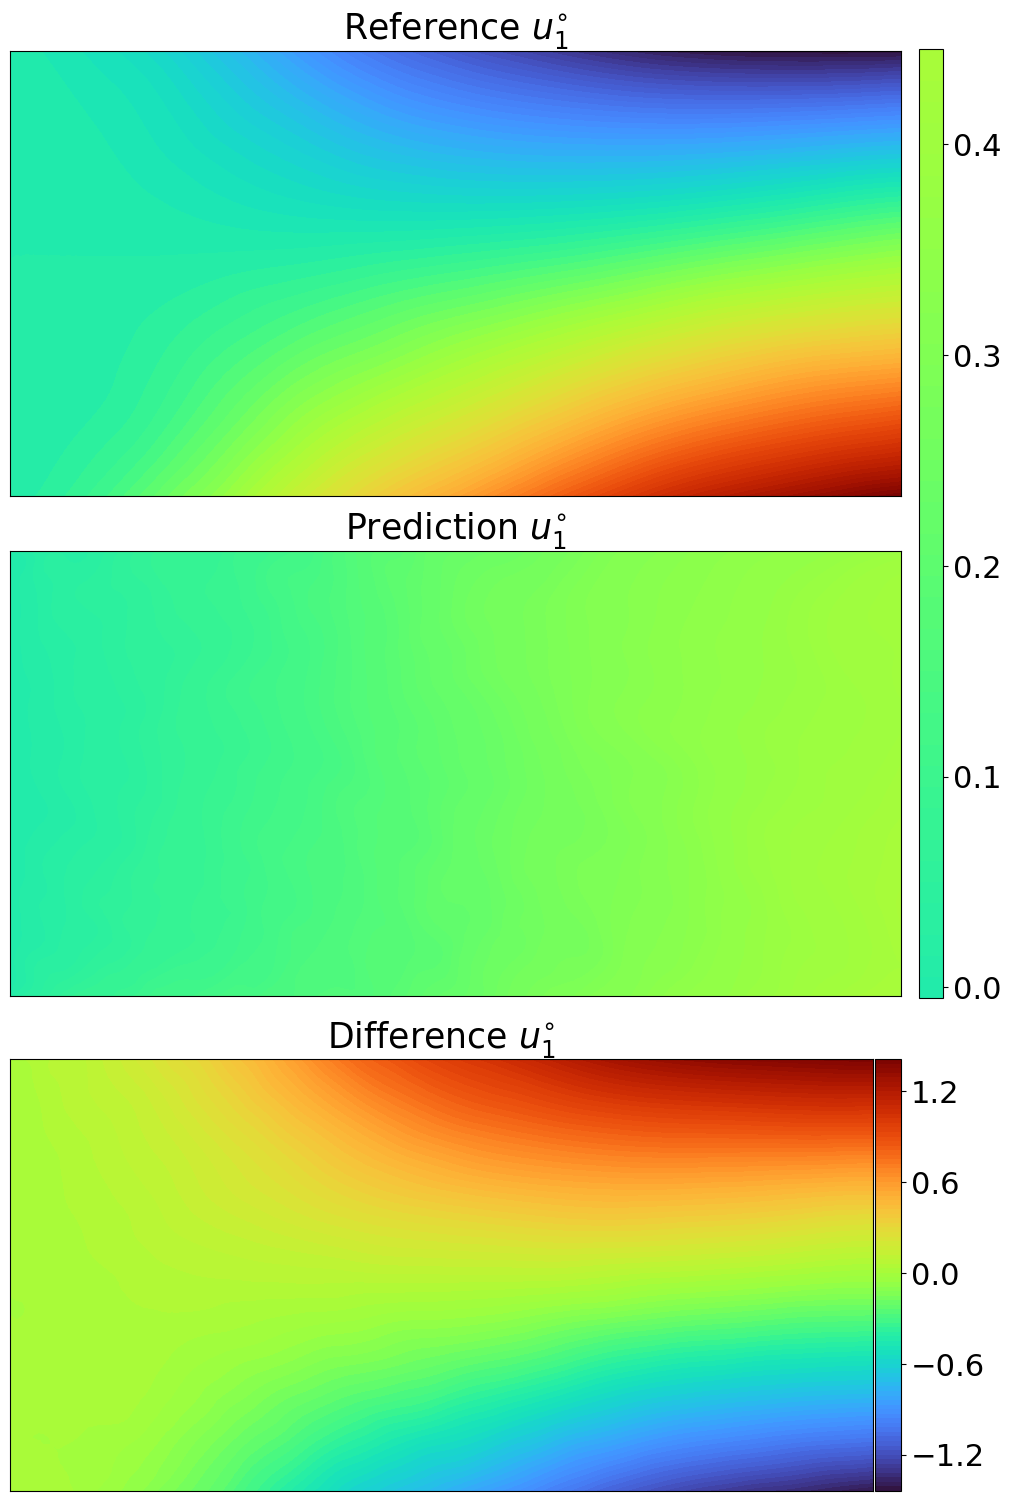

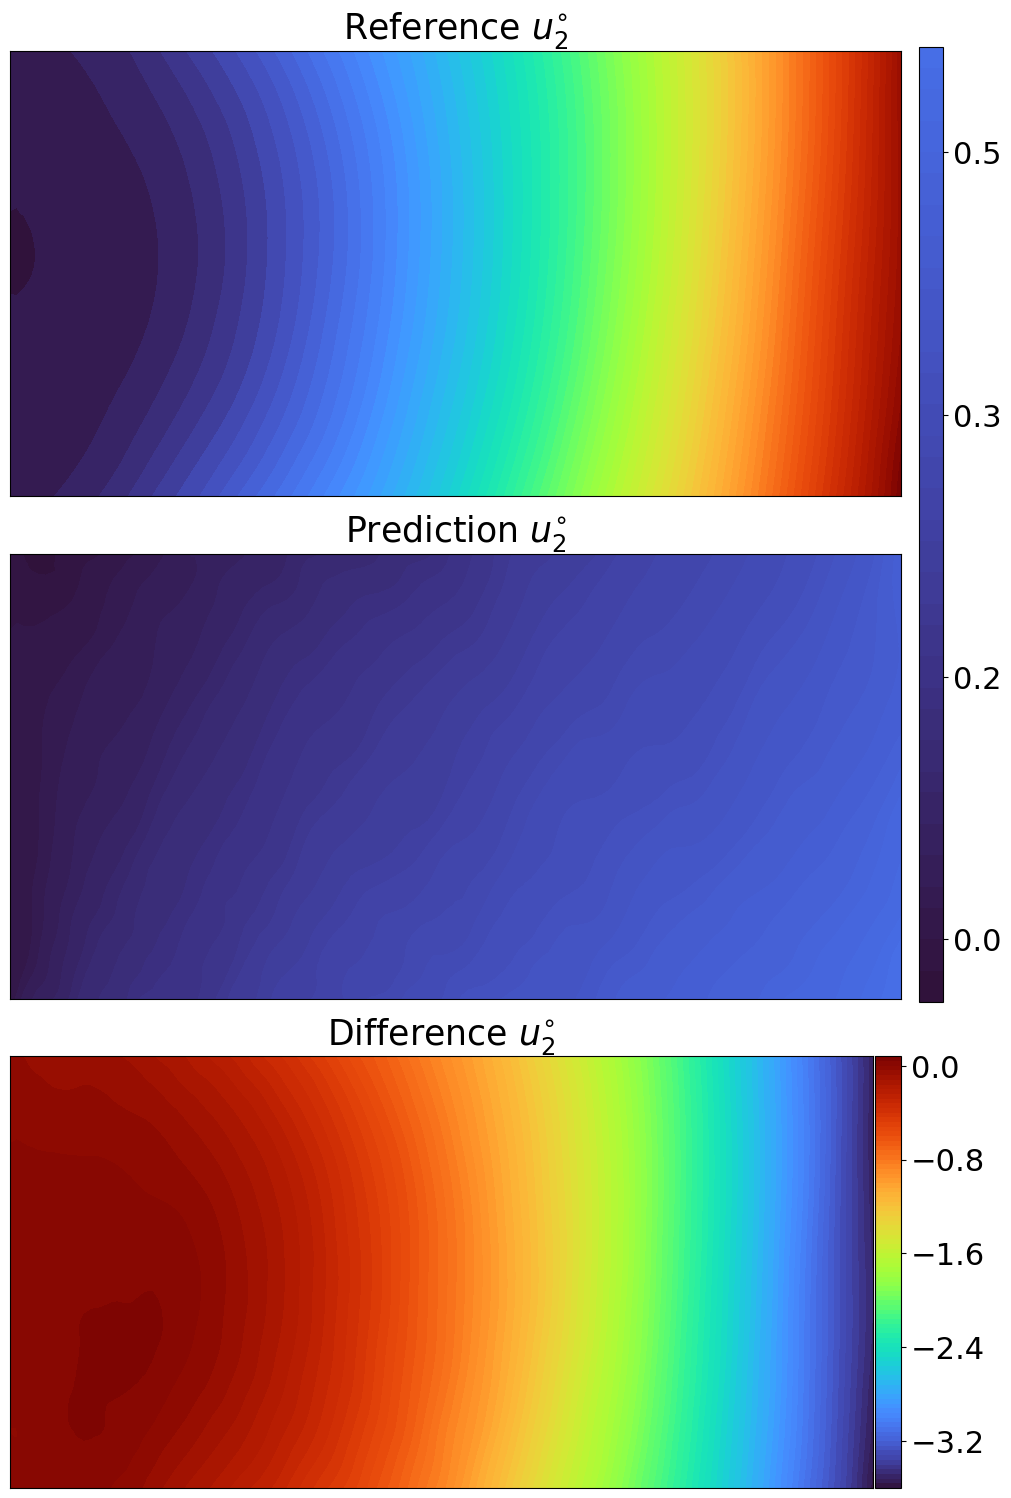

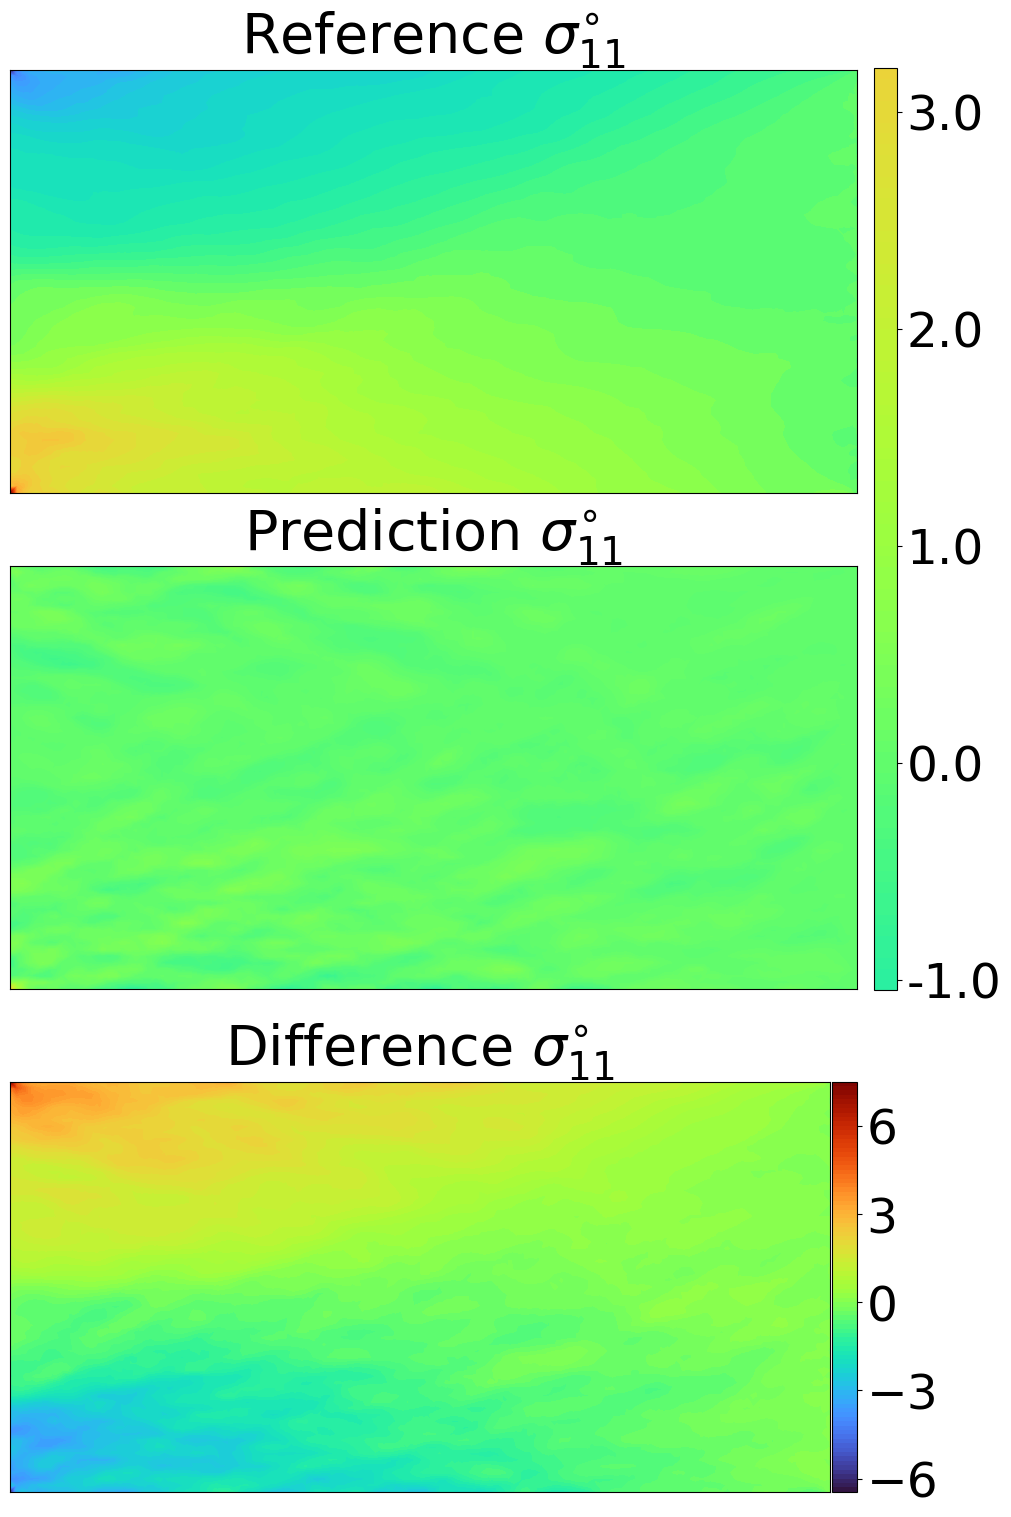

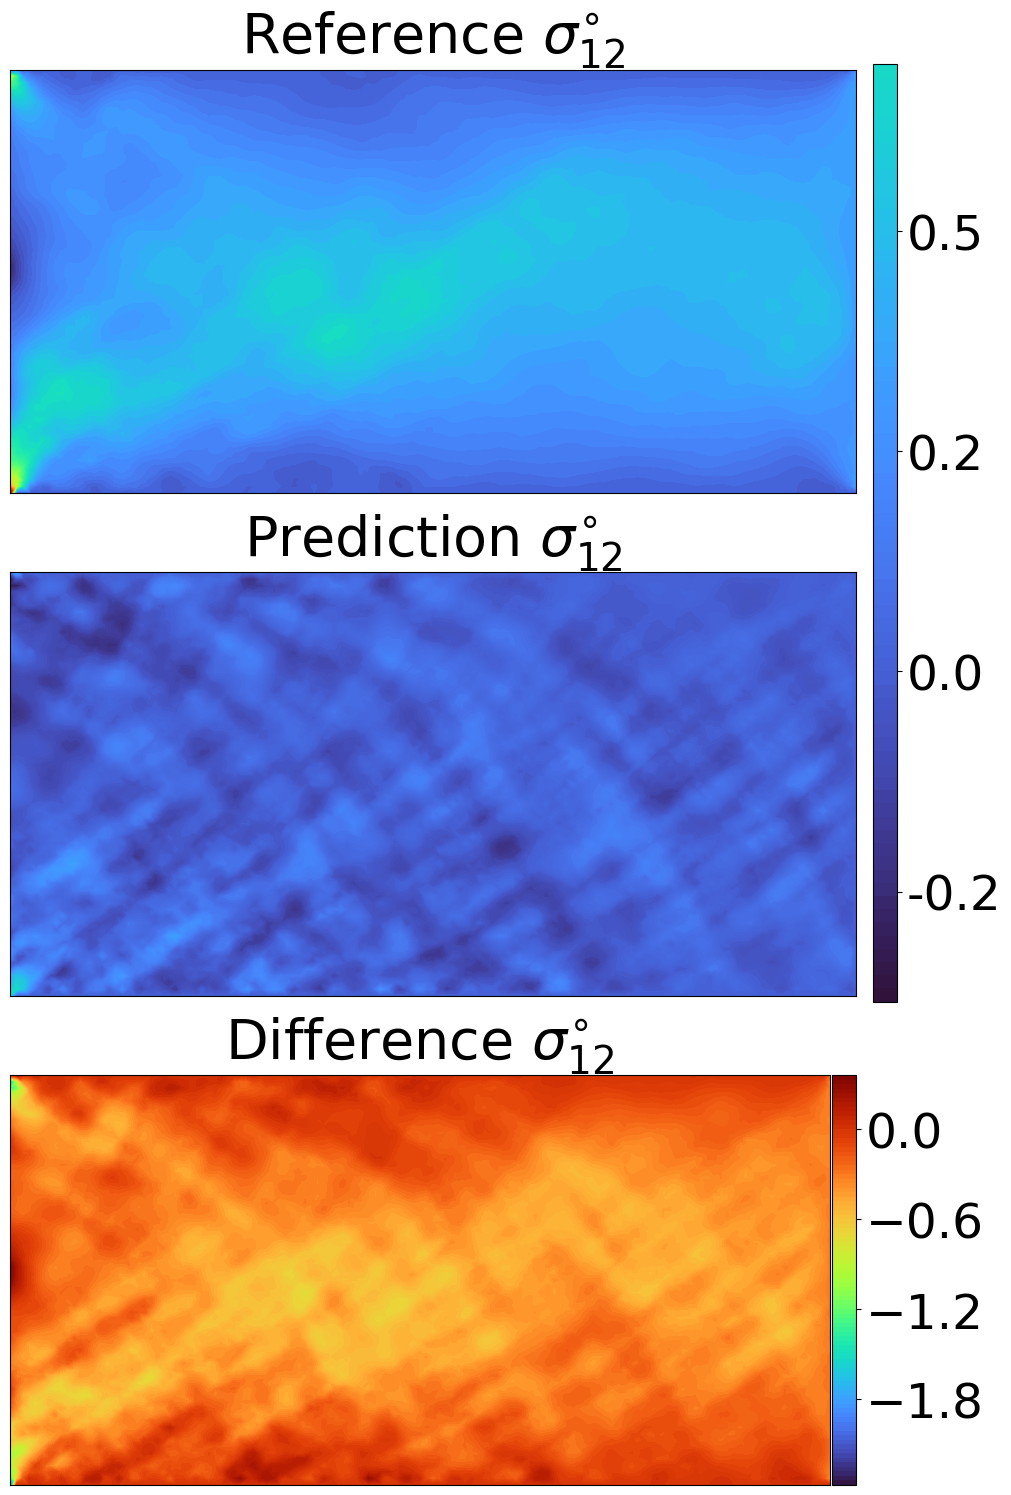

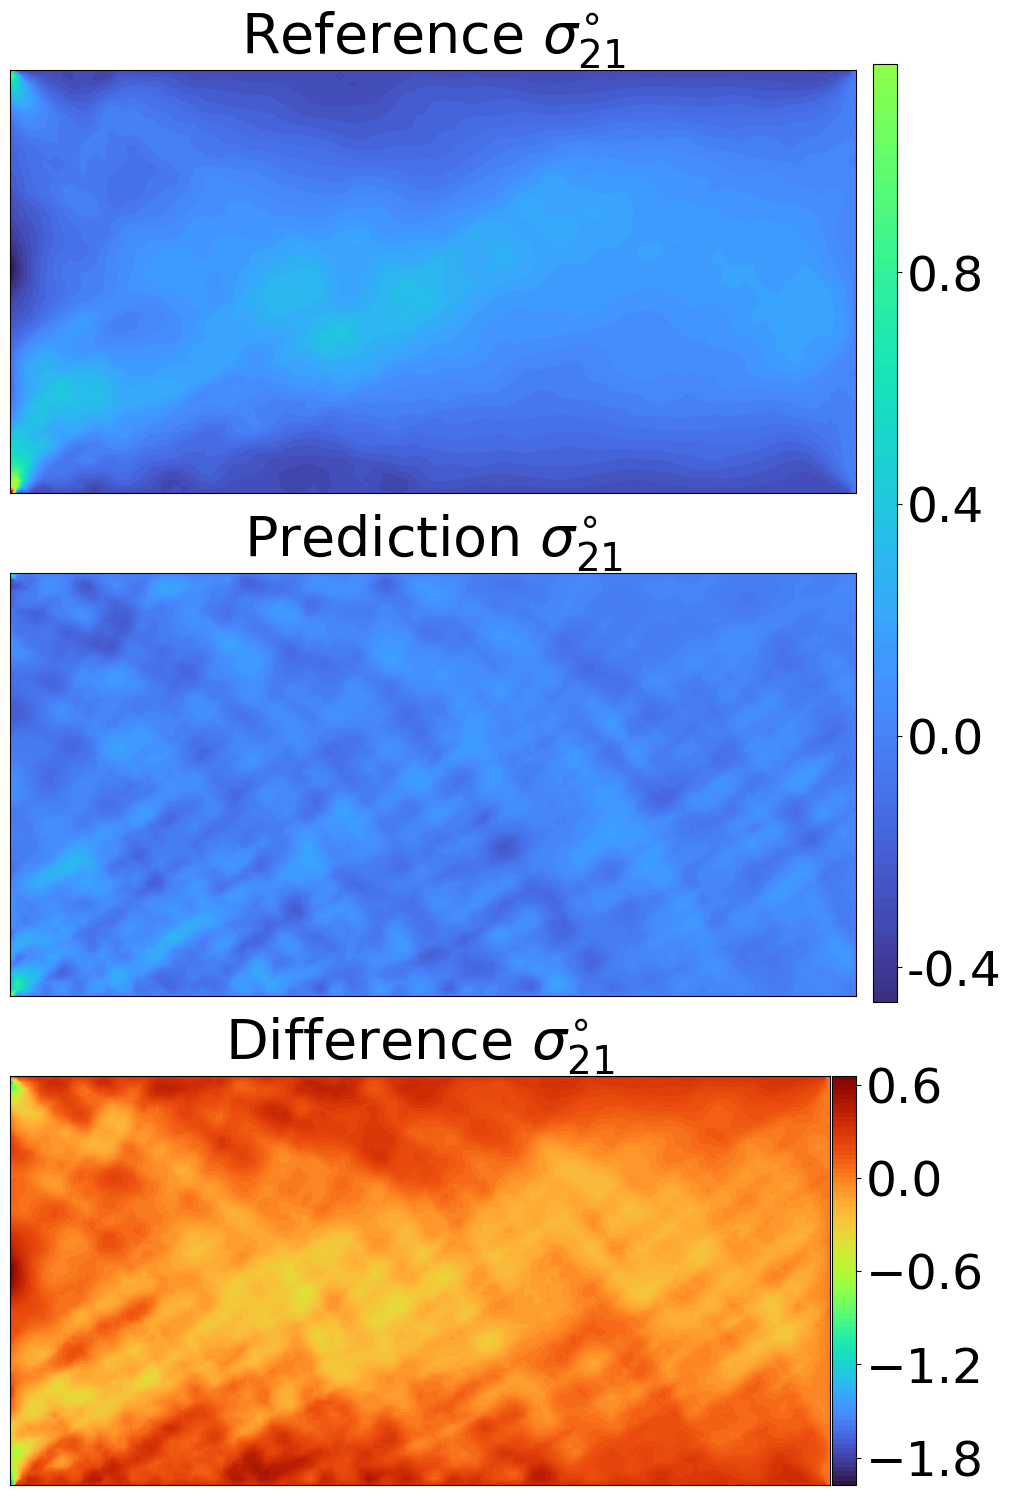

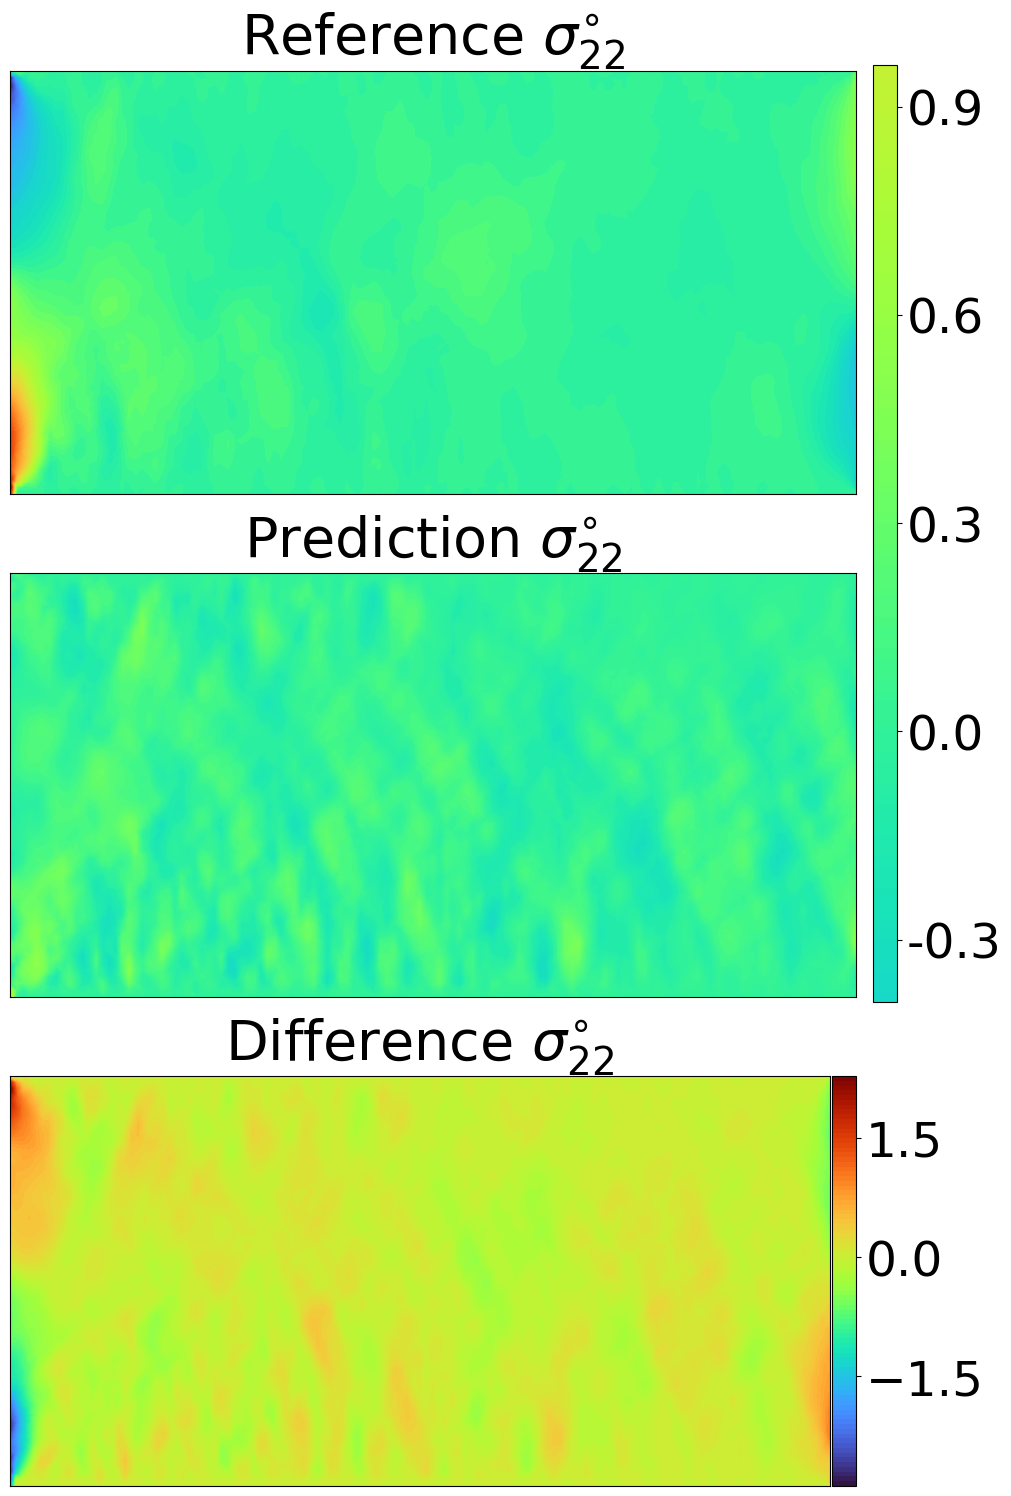

In [60]:
for test_sample_index in range(1):
    pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_sigma_u_fc.x.array[:] = test_pred[test_sample_index]
    pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
    pred_u_fc = pred_sigma_u_fc.sub(1).collapse()
    
    ref_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    ref_sigma_u_fc.x.array[:] = test_sigma_u_dof[test_sample_index]
    ref_sigma_fc = ref_sigma_u_fc.sub(0).collapse()
    ref_u_fc = ref_sigma_u_fc.sub(1).collapse()


    pred_sigma_grid_evals = evaluate_expression(mesh, pred_sigma_fc, mesh.geometry.x)[1]
    pred_u_grid_evals = evaluate_expression(mesh, pred_u_fc, mesh.geometry.x)[1]


    ref_sigma_grid_evals = evaluate_expression(mesh, ref_sigma_fc, mesh.geometry.x)[1]
    ref_u_grid_evals = evaluate_expression(mesh, ref_u_fc, mesh.geometry.x)[1]


    diff_sigma_grid_evals = pred_sigma_grid_evals - ref_sigma_grid_evals
    diff_u_grid_evals = pred_u_grid_evals - ref_u_grid_evals

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]


    u_title_fontsize = 25
    u_tick_labelsize = 22
    u_colorbar_labelsize = 22

    sigma_title_fontsize = 40
    sigma_tick_labelsize = 35
    sigma_colorbar_labelsize = 35

    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,0], pred_u_grid_evals[:,0], diff_u_grid_evals[:,0], r'$u_1^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02,
                            diff_colorbar_pad=0.02, 
                            title_fontsize=u_title_fontsize,
                            tick_labelsize=u_tick_labelsize,
                            colorbar_labelsize=u_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'u1_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,1], pred_u_grid_evals[:,1], diff_u_grid_evals[:,1], r'$u_2^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02,
                            diff_colorbar_pad=0.02,
                            title_fontsize=u_title_fontsize,
                            tick_labelsize=u_tick_labelsize,
                            colorbar_labelsize=u_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'u2_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,0], pred_sigma_grid_evals[:, 0], diff_sigma_grid_evals[:, 0], r'$\sigma_{11}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02,
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_11_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,1], pred_sigma_grid_evals[:, 1], diff_sigma_grid_evals[:, 1], r'$\sigma_{12}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)

    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_12_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,2], pred_sigma_grid_evals[:, 2], diff_sigma_grid_evals[:, 2], r'$\sigma_{21}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)

    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_21_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,3], pred_sigma_grid_evals[:, 3], diff_sigma_grid_evals[:, 3], r'$\sigma_{22}^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_22_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

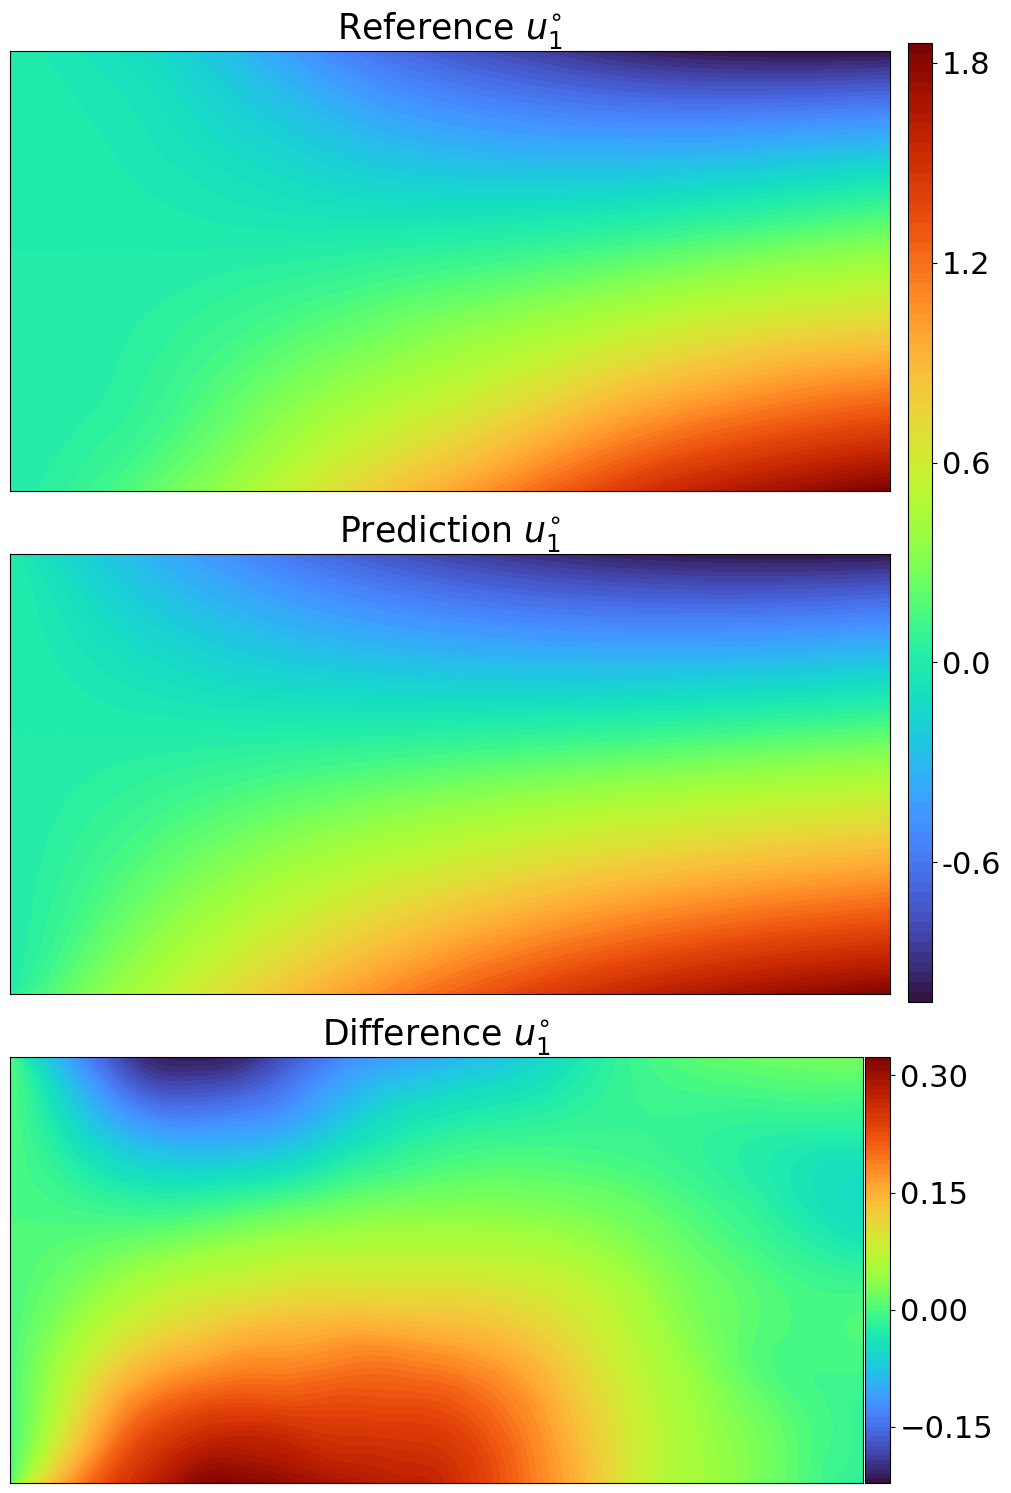

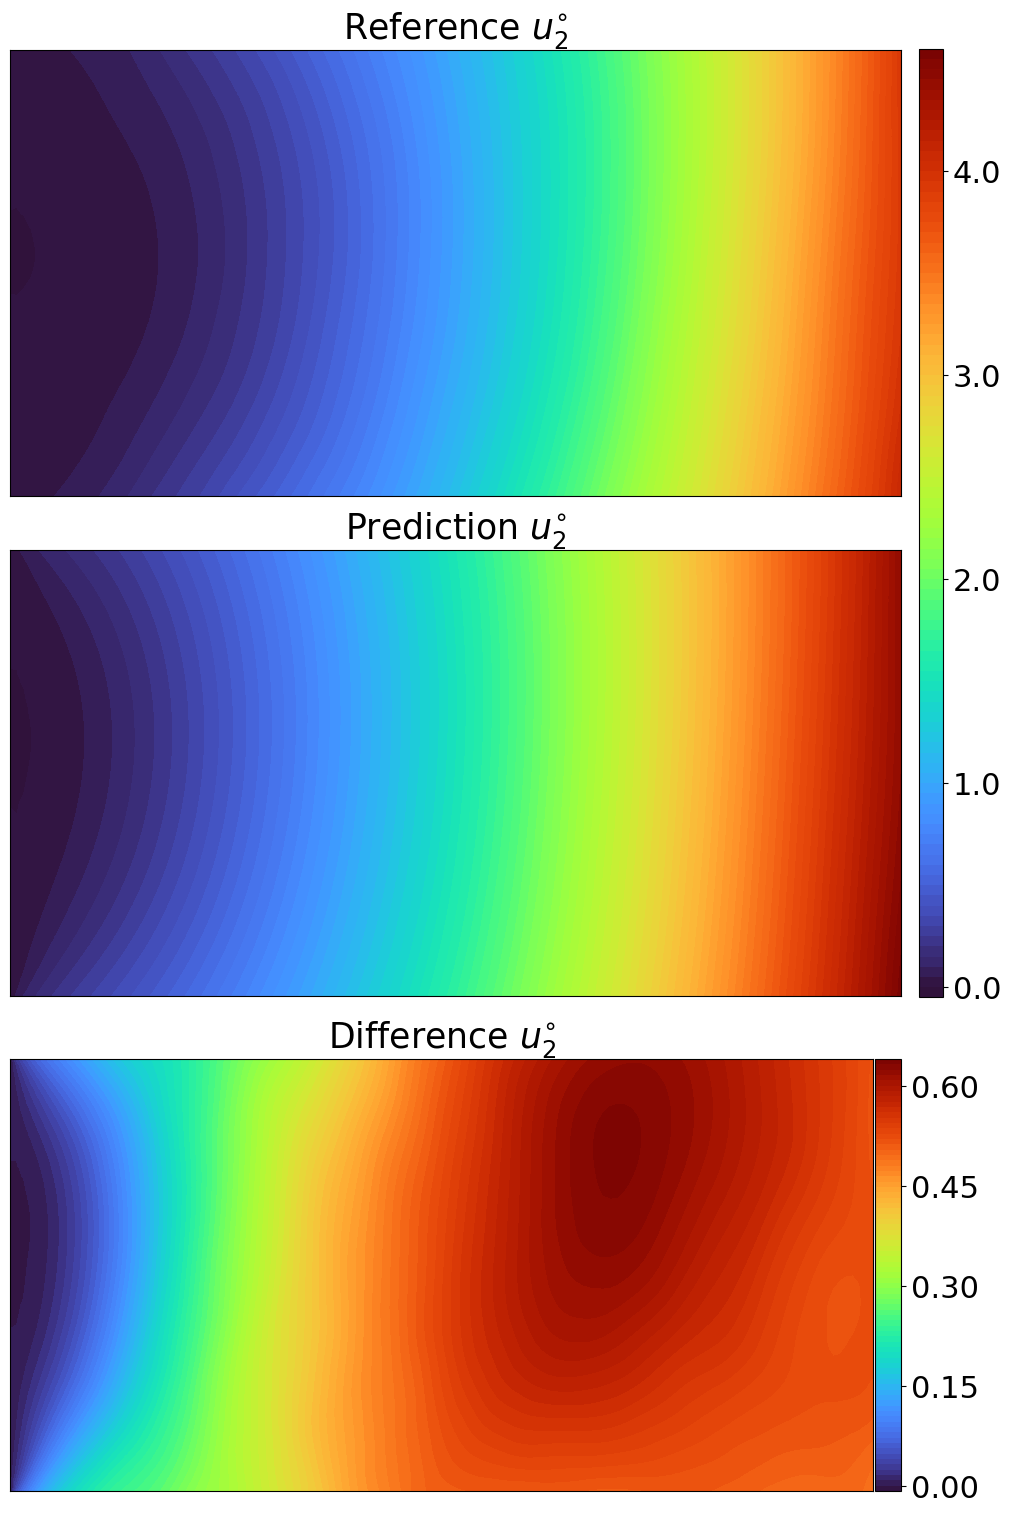

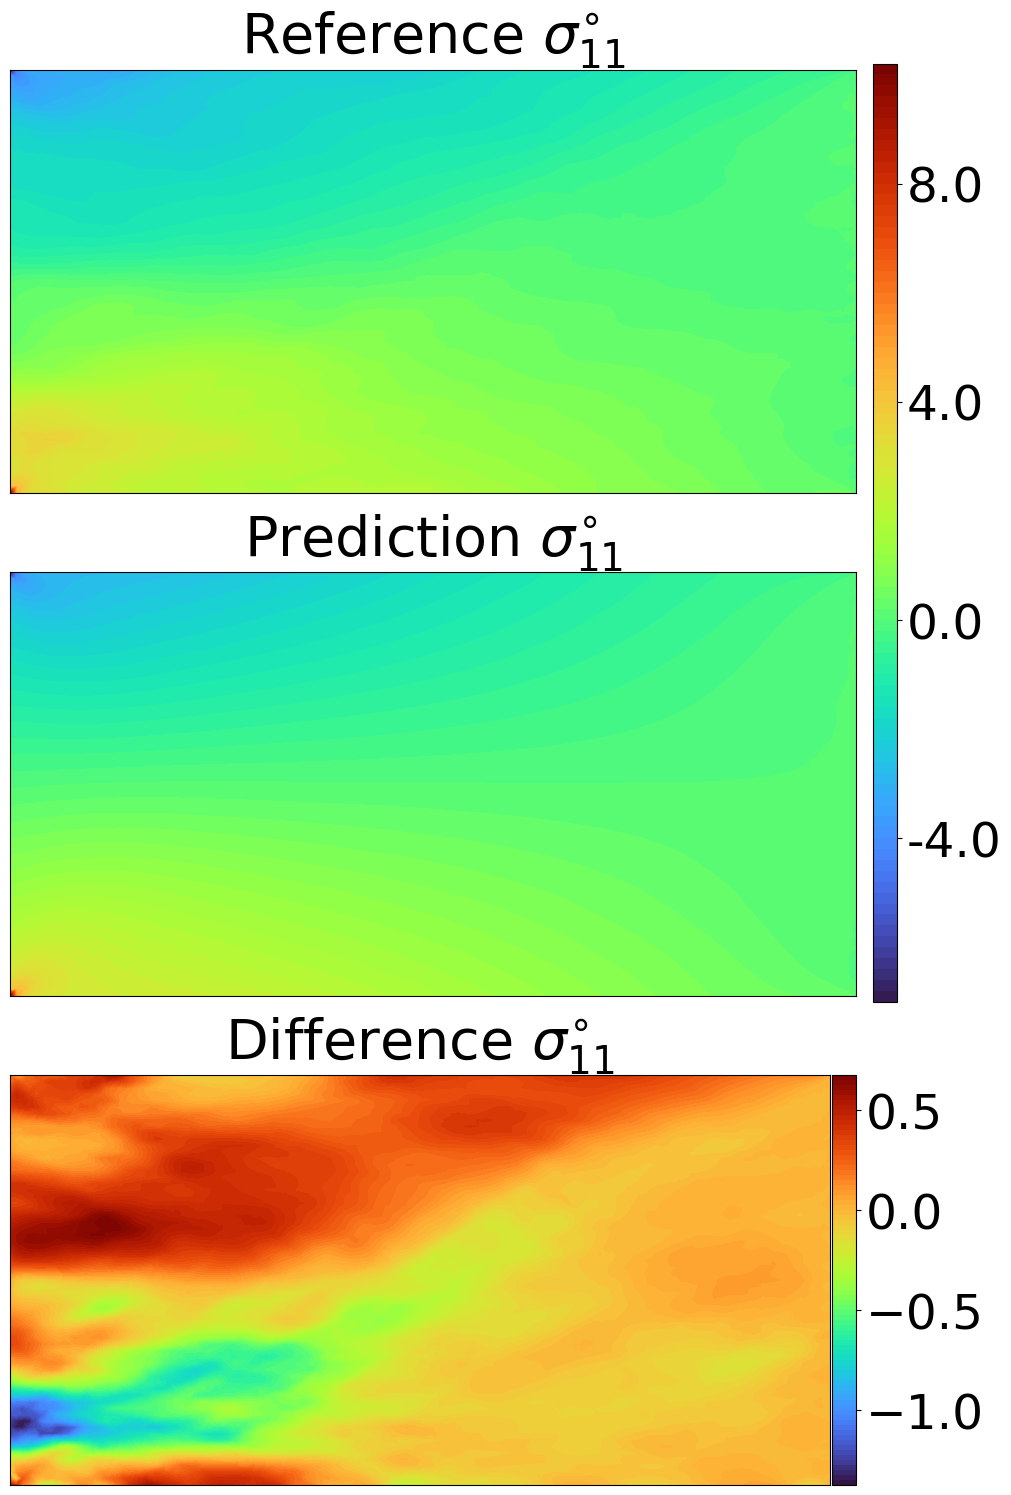

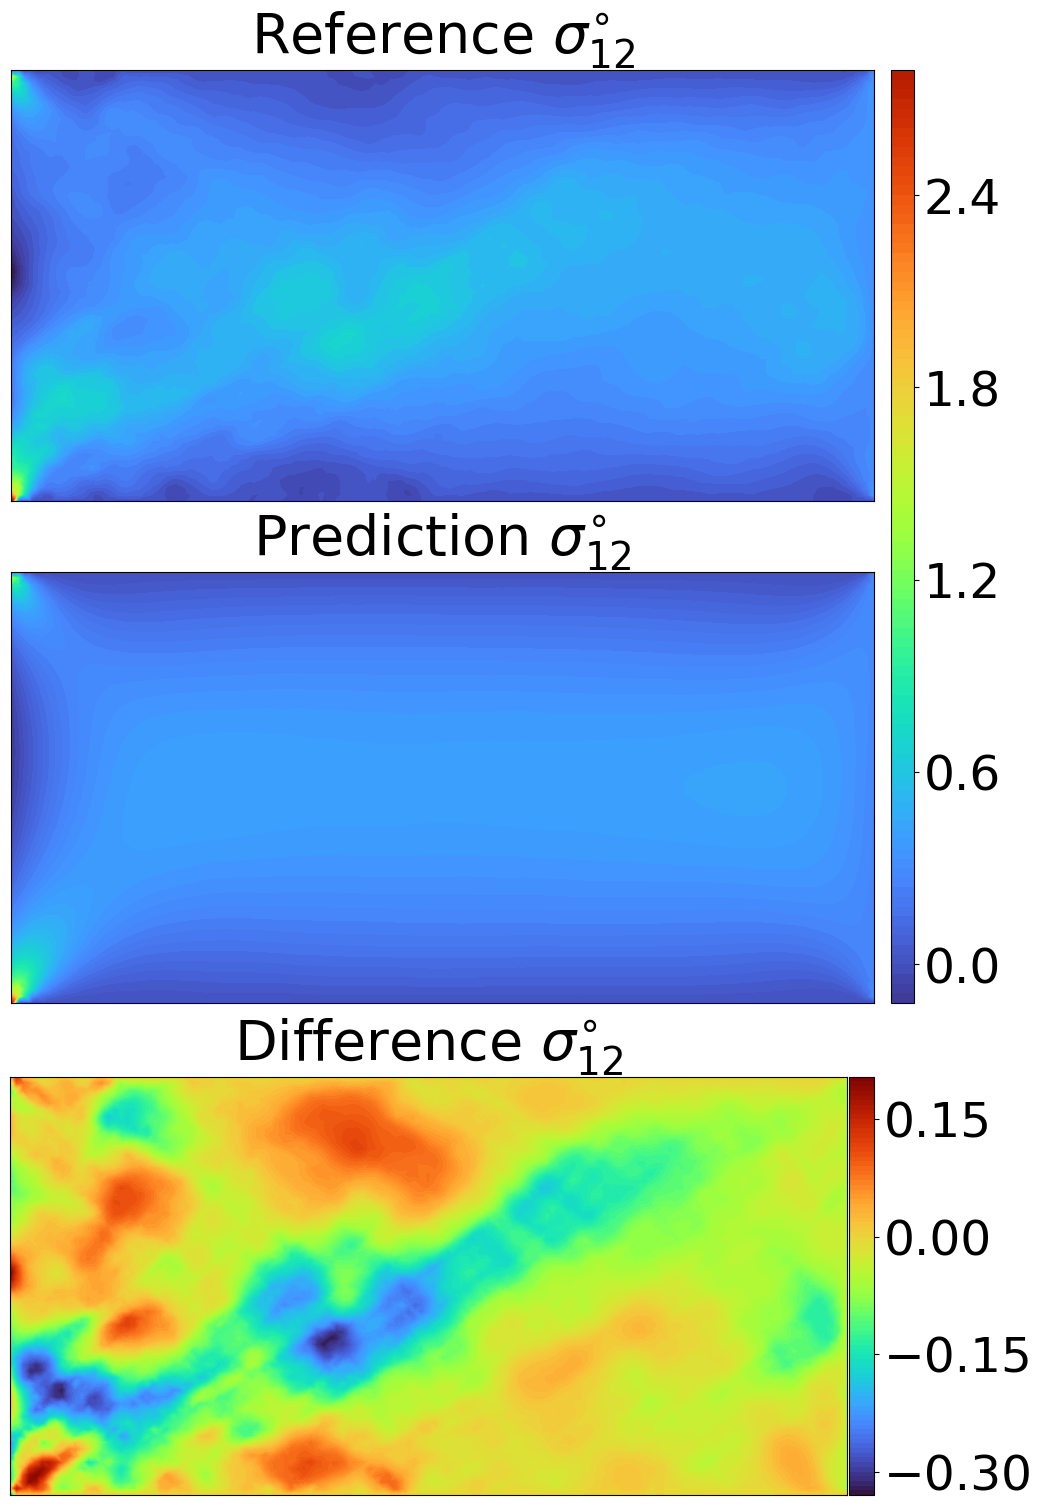

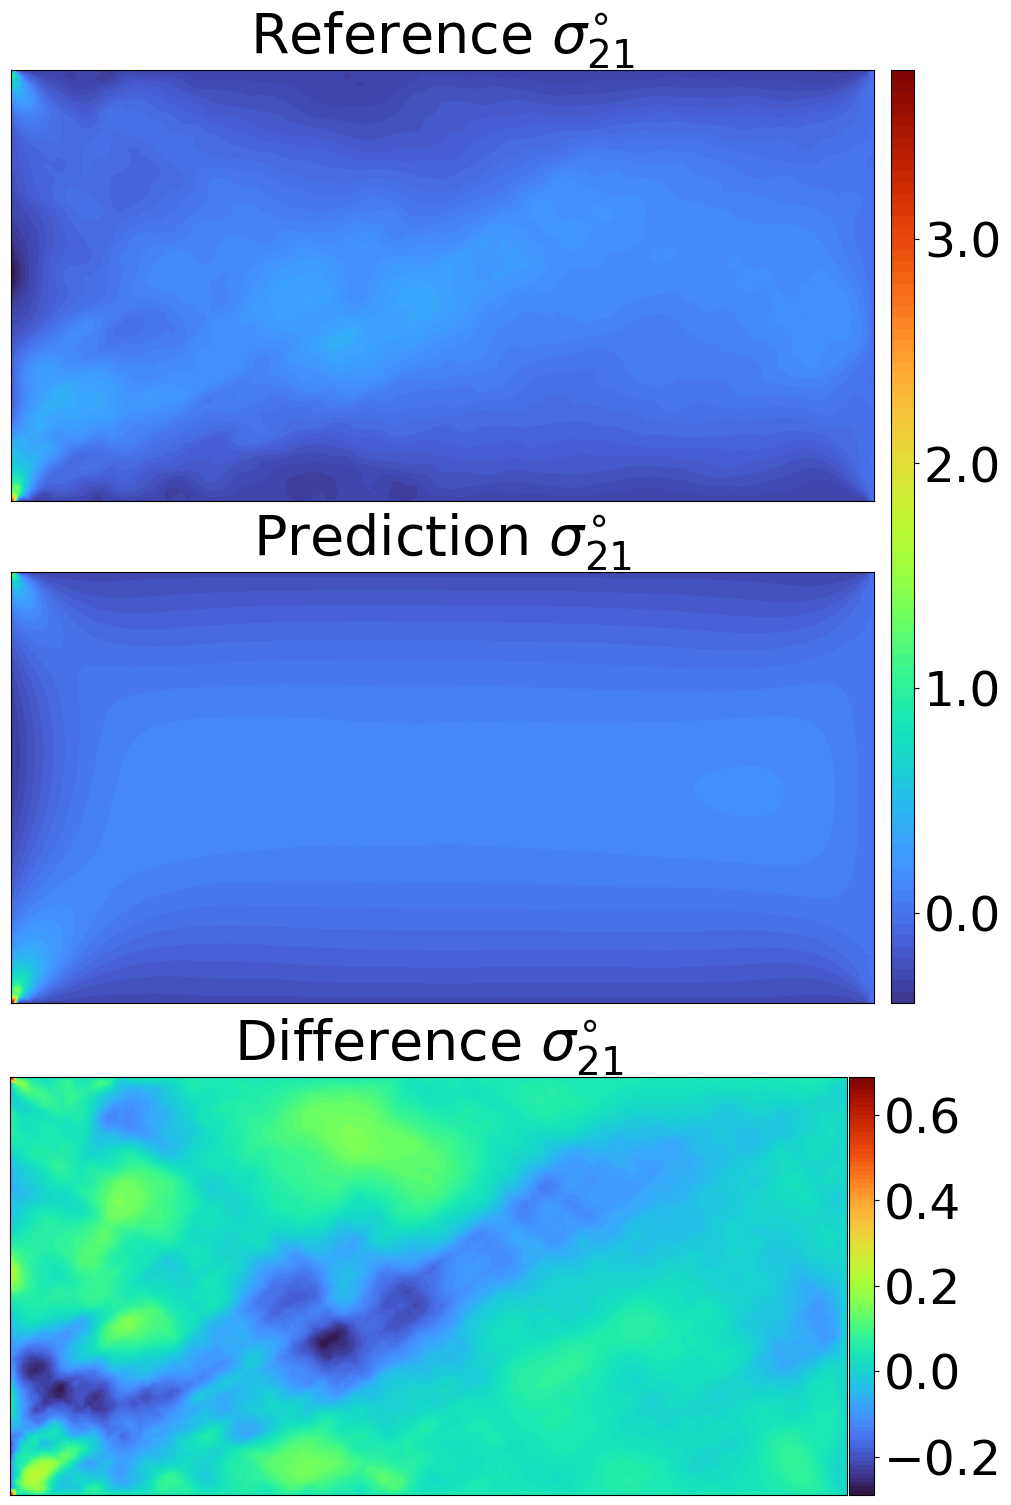

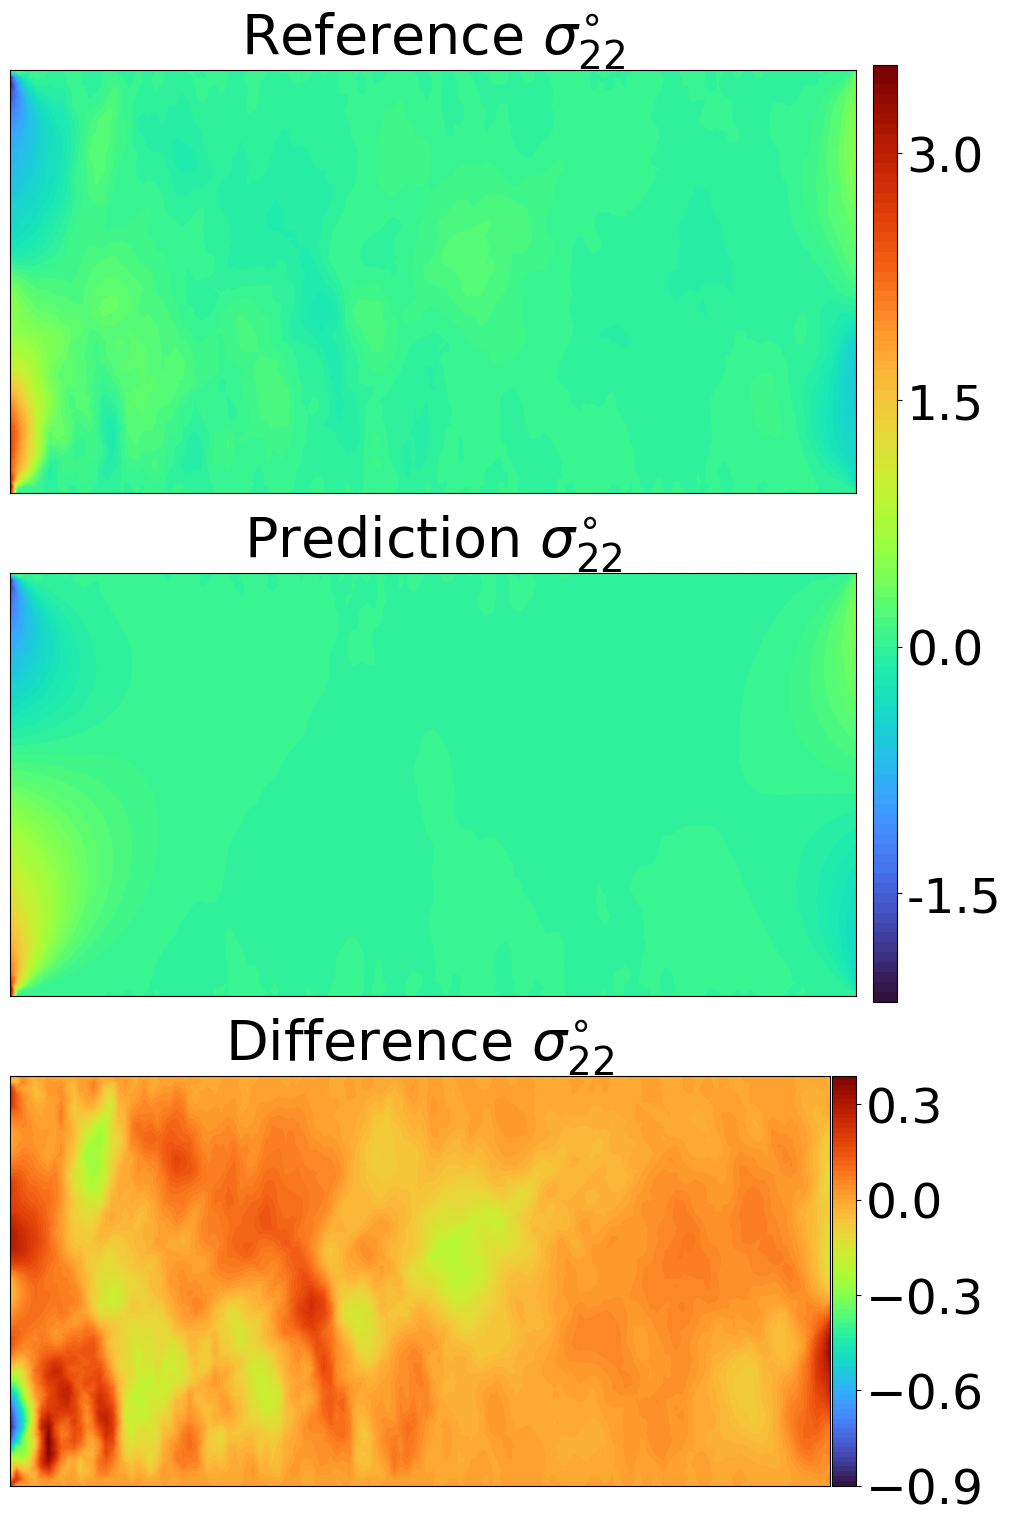

In [61]:
for test_sample_index in range(1):
    pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_sigma_u_fc.x.array[:] = reduced_basis_sigma_u_dof[test_sample_index]
    pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
    pred_u_fc = pred_sigma_u_fc.sub(1).collapse()
    
    ref_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    ref_sigma_u_fc.x.array[:] = test_sigma_u_dof[test_sample_index]
    ref_sigma_fc = ref_sigma_u_fc.sub(0).collapse()
    ref_u_fc = ref_sigma_u_fc.sub(1).collapse()


    pred_sigma_grid_evals = evaluate_expression(mesh, pred_sigma_fc, mesh.geometry.x)[1]
    pred_u_grid_evals = evaluate_expression(mesh, pred_u_fc, mesh.geometry.x)[1]


    ref_sigma_grid_evals = evaluate_expression(mesh, ref_sigma_fc, mesh.geometry.x)[1]
    ref_u_grid_evals = evaluate_expression(mesh, ref_u_fc, mesh.geometry.x)[1]


    diff_sigma_grid_evals = pred_sigma_grid_evals - ref_sigma_grid_evals
    diff_u_grid_evals = pred_u_grid_evals - ref_u_grid_evals

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]


    u_title_fontsize = 25
    u_tick_labelsize = 22
    u_colorbar_labelsize = 22

    sigma_title_fontsize = 40
    sigma_tick_labelsize = 35
    sigma_colorbar_labelsize = 35

    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,0], pred_u_grid_evals[:,0], diff_u_grid_evals[:,0], r'$u_1^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02,
                            diff_colorbar_pad=0.02, 
                            title_fontsize=u_title_fontsize,
                            tick_labelsize=u_tick_labelsize,
                            colorbar_labelsize=u_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'u1_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,1], pred_u_grid_evals[:,1], diff_u_grid_evals[:,1], r'$u_2^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02,
                            diff_colorbar_pad=0.02,
                            title_fontsize=u_title_fontsize,
                            tick_labelsize=u_tick_labelsize,
                            colorbar_labelsize=u_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'u2_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,0], pred_sigma_grid_evals[:, 0], diff_sigma_grid_evals[:, 0], r'$\sigma_{11}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02,
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_11_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,1], pred_sigma_grid_evals[:, 1], diff_sigma_grid_evals[:, 1], r'$\sigma_{12}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)

    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_12_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,2], pred_sigma_grid_evals[:, 2], diff_sigma_grid_evals[:, 2], r'$\sigma_{21}^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)

    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_21_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,3], pred_sigma_grid_evals[:, 3], diff_sigma_grid_evals[:, 3], r'$\sigma_{22}^{\circ}$',
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.02, 
                            diff_colorbar_pad=0.02, 
                            title_fontsize=sigma_title_fontsize,
                            tick_labelsize=sigma_tick_labelsize,
                            colorbar_labelsize=sigma_colorbar_labelsize)
    # fig.savefig(os.path.join(model_test_outputs_path, f'sigma_22_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

In [5]:
bochner_hdiv_h1_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    bochner_hdiv_h1_error_list.append(np.mean(sigma_u_error_dict['squared_hdiv_h1']).item())

In [6]:
bochner_hdiv_h1_error_list

[3.13521796012159,
 0.16936386667947326,
 0.0774816040567801,
 0.021273377936936604,
 0.005378393755694711]

In [62]:
finer_sigma_u_error_dict_list = []
for num_train in num_train_list:
    finer_sigma_u_error_dict = np.load(os.path.join(model_test_outputs_path, f'finer_sigma_u_error_dict_{num_train}.npy'), allow_pickle=True).item()
    finer_sigma_u_error_dict_list.append(finer_sigma_u_error_dict)

In [63]:
finer_bochner_hdiv_h1_error_list = []
for finer_sigma_u_error_dict in finer_sigma_u_error_dict_list:
    finer_bochner_hdiv_h1_error_list.append(np.mean(finer_sigma_u_error_dict['squared_hdiv_h1']).item())

In [64]:
finer_bochner_hdiv_h1_error_list

[3.1791406747725732,
 0.17465812083697166,
 0.0808777463314427,
 0.02461435377854248,
 0.0072266452981627725]

In [65]:
physics_loss_list = []
for num_train in num_train_list:
    physics_loss = np.load(os.path.join(model_test_outputs_path, f'residual_loss_dict_{num_train}.npy'), allow_pickle=True).item()
    physics_loss_list.append(physics_loss)

In [66]:
mean_residual_loss_list = []
for physics_loss in physics_loss_list:
    mean_residual_loss = physics_loss['mean_total_residual_loss'].item()
    mean_residual_loss_list.append(mean_residual_loss)

In [67]:
mean_residual_loss_list

[0.26910580760806063,
 0.18871092207265364,
 0.08609113385419848,
 0.011219637062377953,
 0.004573440614427145]

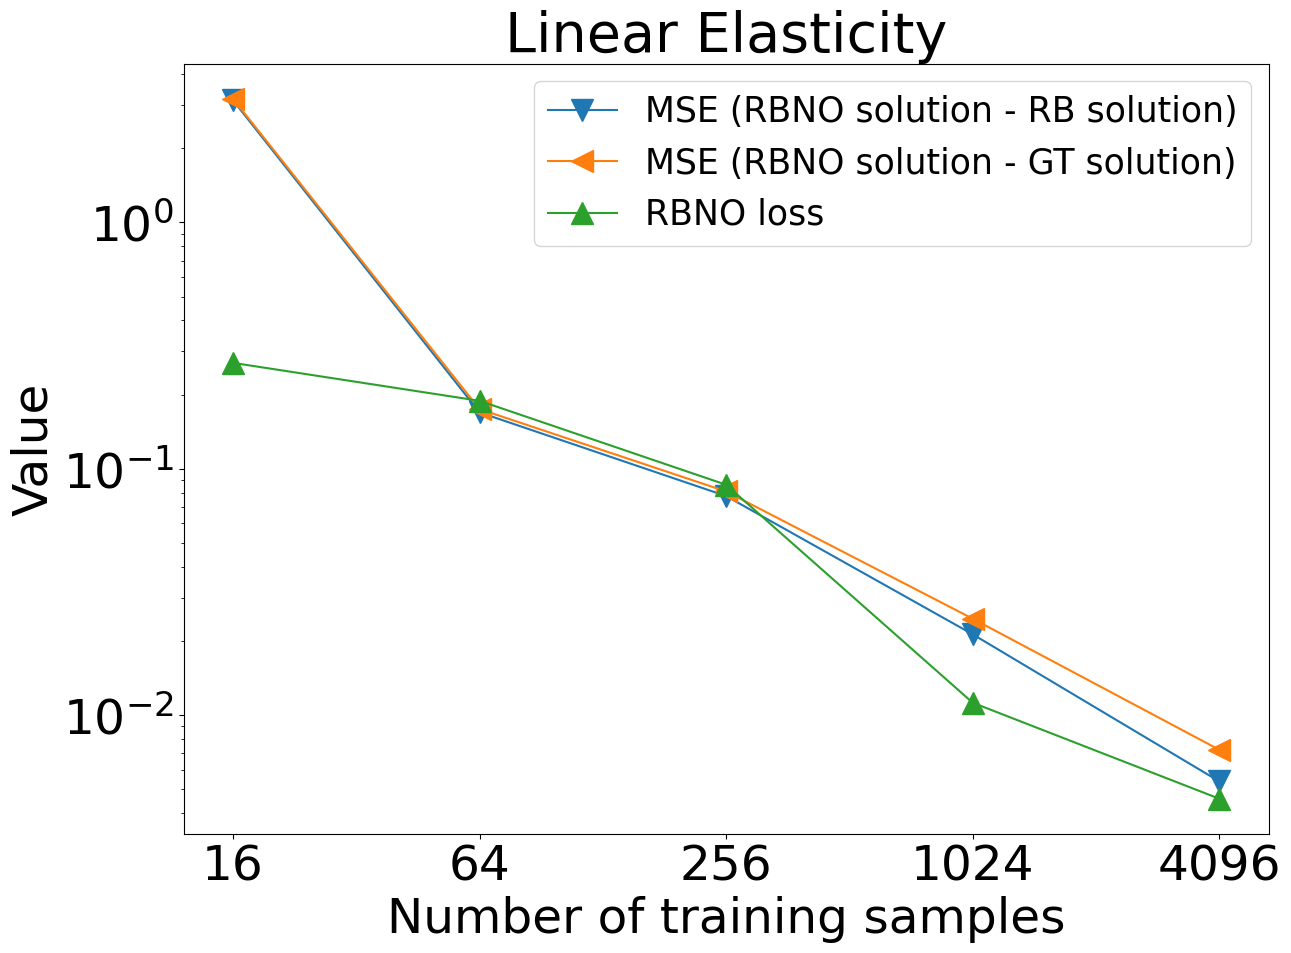

In [68]:
plt.figure(figsize=(14,10))
plt.plot(num_train_list, bochner_hdiv_h1_error_list, marker='v', markersize=16, label='MSE (RBNO solution - RB solution)')
plt.plot(num_train_list, finer_bochner_hdiv_h1_error_list, marker='<',  markersize=16, label='MSE (RBNO solution - GT solution)')
plt.plot(num_train_list, mean_residual_loss_list, marker='^', markersize=16, label='RBNO loss')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of training samples', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_train_list, num_train_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=25, loc='upper right')
plt.title('Linear Elasticity', fontsize=40)
plt.savefig(os.path.join(model_test_outputs_path , "mse_and_loss_vs_num_train.png"), dpi=300, bbox_inches='tight')
plt.show()